# Öğrenci Sınav Puanlarını Tahmin Etme

Bu projede amaç; öğrencinin demografik bilgileri, çalışma alışkanlıkları, uyku durumu ve çevresel faktörlerine bakarak sınav puanını tahmin etmek

**student_id**: Her öğrenciyi veri seti içerisinde benzersiz şekilde tanımlayan kimlik numarasıdır.

**age:** Öğrencinin yaşını yıl cinsinden ifade eden demografik bir değişkendir.

**gender:** Öğrencinin cinsiyet bilgisini (male, female, other) gösteren kategorik bir değişkendir.

**course:** Öğrencinin kayıtlı olduğu akademik program türünü belirtir.

**study_hours:** Öğrencinin günlük ortalama ders çalışma süresini saat cinsinden ifade eder.

**class_attendance:** Öğrencinin derslere katılım oranını yüzde (%) cinsinden göstermektedir.

**internet_access:** Öğrencinin internete erişiminin olup olmadığını belirten ikili (yes/no) bir değişkendir.

**sleep_hours:** Öğrencinin günlük ortalama uyku süresini saat cinsinden ifade eder.

**sleep_quality:** Öğrencinin uyku kalitesini nitel olarak (poor, average, good) tanımlar.

**study_method:** Öğrencinin ağırlıklı olarak kullandığı çalışma yöntemini belirtir.

**facility_rating:** Öğrencinin eğitim aldığı ortamın imkân düzeyini (low, medium, high) gösterir.

**exam_difficulty:** Öğrencinin sınavı algıladığı zorluk seviyesini (easy, moderate, hard) ifade eder.

**exam_score:** Öğrencinin sınavdan aldığı nihai puanı temsil eden hedef değişkendir.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s6e1/sample_submission.csv
/kaggle/input/playground-series-s6e1/train.csv
/kaggle/input/playground-series-s6e1/test.csv
/kaggle/input/exam-score-prediction-dataset/Exam_Score_Prediction.csv


In [2]:
# ===============================
# TEMEL KÜTÜPHANELER
# ===============================
import numpy as np
import pandas as pd

# ===============================
# GÖRSELLEŞTİRME (EDA)
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# VERİ ÖN İŞLEME
# ===============================
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ===============================
# REGRESYON MODELLERİ
# ===============================
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ===============================
# MODEL DEĞERLENDİRME
# ===============================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ===============================
# FEATURE IMPORTANCE / AÇIKLANABİLİRLİK
# ===============================
from sklearn.inspection import permutation_importance

# ===============================
# (OPSİYONEL – DAHA GÜÇLÜ MODELLER)
# ===============================
# Eğer Kaggle ortamında kuruluysa
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ===============================
# UYARILARI KAPAT (opsiyonel)
# ===============================
import warnings
warnings.filterwarnings("ignore")


In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    for filename in filenames:
        print("  -", filename)


/kaggle/input
/kaggle/input/playground-series-s6e1
  - sample_submission.csv
  - train.csv
  - test.csv
/kaggle/input/exam-score-prediction-dataset
  - Exam_Score_Prediction.csv


In [4]:
import pandas as pd

path = "/kaggle/input/exam-score-prediction-dataset/Exam_Score_Prediction.csv"
df = pd.read_csv(path)

df.head()


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [5]:
df.shape

(20000, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [7]:
df.columns

Index(['student_id', 'age', 'gender', 'course', 'study_hours',
       'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality',
       'study_method', 'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

In [8]:
df.describe()

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000


In [9]:
df.isnull().sum()

student_id          0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [10]:
df.corr(numeric_only=True)

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
student_id,1.000000,-0.002574,0.002116,0.001128,-0.000560,0.003269
age,-0.002574,1.000000,0.002955,0.008449,-0.000385,0.006522
study_hours,0.002116,0.002955,1.000000,-0.001645,-0.004533,0.717788
class_attendance,0.001128,0.008449,-0.001645,1.000000,0.007187,0.308850
sleep_hours,-0.000560,-0.000385,-0.004533,0.007187,1.000000,0.133222
exam_score,0.003269,0.006522,0.717788,0.308850,0.133222,1.000000


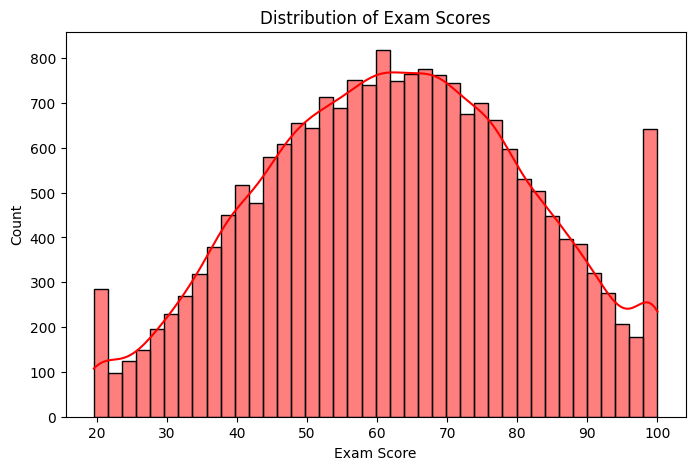

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    df['exam_score'],
    bins=40,
    kde=True,
    color='red'
)

plt.xlabel("Exam Score")
plt.ylabel("Count")
plt.title("Distribution of Exam Scores")

plt.show()


Sınav puanlarının dağılımı incelendiğinde, puanların çoğunlukla orta–yüksek aralıkta toplandığı ve dağılımın yaklaşık olarak çan eğrisi (normal dağılım) yapısına yakın olduğu görülmektedir.

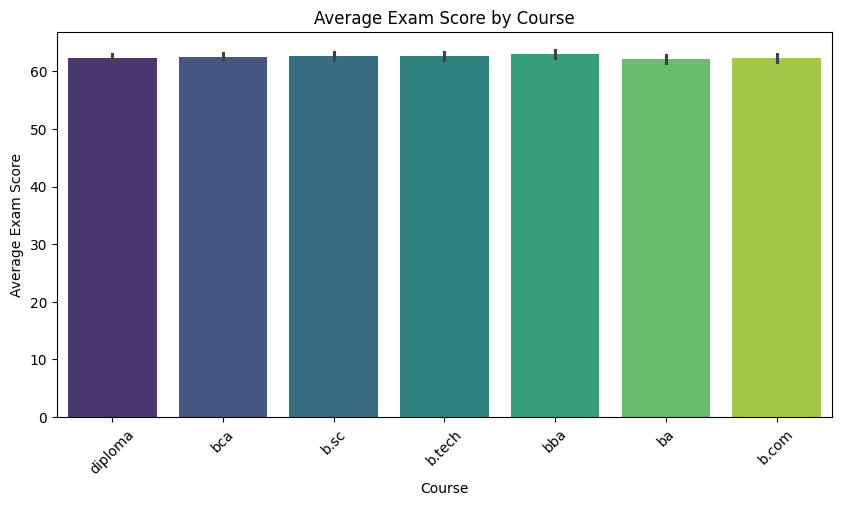

In [12]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='course',
    y='exam_score',
    data=df,
    palette='viridis'
)

plt.xticks(rotation=45)
plt.xlabel("Course")
plt.ylabel("Average Exam Score")
plt.title("Average Exam Score by Course")

plt.show()


Farklı akademik programlar arasında ortalama sınav puanlarının büyük ölçüde benzer olduğu ve program türünün sınav başarısı üzerinde sınırlı bir etkiye sahip olduğu anlaşılmaktadır.

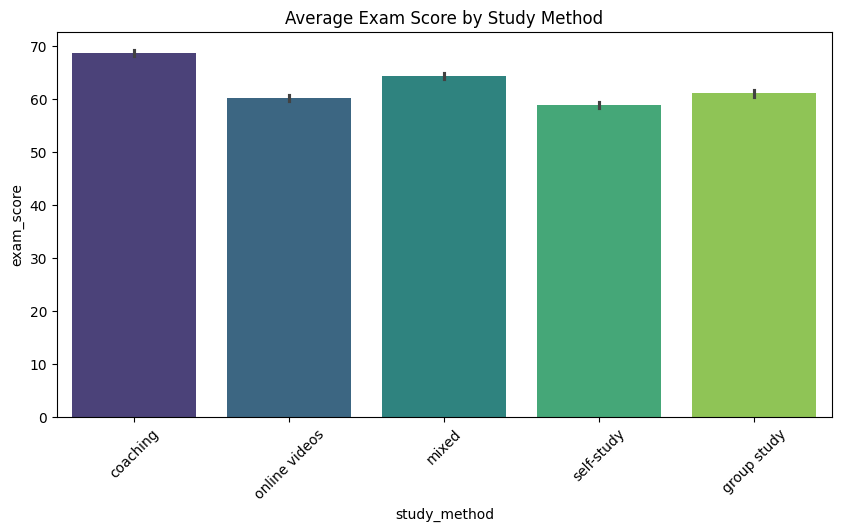

In [13]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='study_method',
    y='exam_score',
    data=df,
    palette='viridis'
)

plt.xticks(rotation=45)
plt.title("Average Exam Score by Study Method")
plt.show()


Grafik incelendiğinde, koçluk (coaching) ve karma (mixed) çalışma yöntemlerini kullanan öğrencilerin ortalama sınav puanlarının diğer yöntemlere kıyasla daha yüksek olduğu görülmektedir.

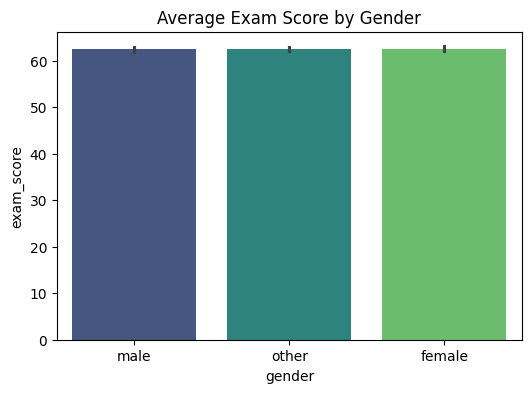

In [14]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='gender',
    y='exam_score',
    data=df,
    palette='viridis'
)

plt.title("Average Exam Score by Gender")
plt.show()


Grafik, cinsiyet grupları arasında ortalama sınav puanlarının birbirine oldukça yakın olduğunu ve cinsiyetin sınav başarısı üzerinde belirgin bir fark yaratmadığını göstermektedir.

In [15]:
df = pd.get_dummies(df, columns=['gender'], drop_first=True)


In [16]:
df['internet_access'] = df['internet_access'].map({'no': 0, 'yes': 1})


In [17]:
sleep_map = {'poor': 0, 'average': 1, 'good': 2}
df['sleep_quality'] = df['sleep_quality'].map(sleep_map)


In [18]:
facility_map = {'low': 0, 'medium': 1, 'high': 2}
df['facility_rating'] = df['facility_rating'].map(facility_map)


In [19]:
difficulty_map = {'easy': 0, 'moderate': 1, 'hard': 2}
df['exam_difficulty'] = df['exam_difficulty'].map(difficulty_map)


In [20]:
df = pd.get_dummies(df, columns=['course'], drop_first=True)


In [21]:
df = pd.get_dummies(df, columns=['study_method'], drop_first=True)


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  20000 non-null  int64  
 1   age                         20000 non-null  int64  
 2   study_hours                 20000 non-null  float64
 3   class_attendance            20000 non-null  float64
 4   internet_access             20000 non-null  int64  
 5   sleep_hours                 20000 non-null  float64
 6   sleep_quality               20000 non-null  int64  
 7   facility_rating             20000 non-null  int64  
 8   exam_difficulty             20000 non-null  int64  
 9   exam_score                  20000 non-null  float64
 10  gender_male                 20000 non-null  bool   
 11  gender_other                20000 non-null  bool   
 12  course_b.sc                 20000 non-null  bool   
 13  course_b.tech               200

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  20000 non-null  int64  
 1   age                         20000 non-null  int64  
 2   study_hours                 20000 non-null  float64
 3   class_attendance            20000 non-null  float64
 4   internet_access             20000 non-null  int64  
 5   sleep_hours                 20000 non-null  float64
 6   sleep_quality               20000 non-null  int64  
 7   facility_rating             20000 non-null  int64  
 8   exam_difficulty             20000 non-null  int64  
 9   exam_score                  20000 non-null  float64
 10  gender_male                 20000 non-null  bool   
 11  gender_other                20000 non-null  bool   
 12  course_b.sc                 20000 non-null  bool   
 13  course_b.tech               200

In [24]:
df.head()

,student_id,age,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,facility_rating,exam_difficulty,exam_score,...,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study
0,1,17,2.78,92.9,1,7.4,0,0,2,58.9,...,False,False,False,False,False,True,False,False,False,False
1,2,23,3.37,64.8,1,4.6,1,1,1,54.8,...,False,False,False,False,True,False,False,False,True,False
2,3,22,7.88,76.8,1,8.5,0,2,1,90.3,...,True,False,False,False,False,False,False,False,False,False
3,4,20,0.67,48.4,1,5.8,1,0,1,29.7,...,False,False,False,False,False,True,False,False,True,False
4,5,20,0.89,71.6,1,9.8,0,0,1,43.7,...,False,False,False,False,False,True,False,False,False,False


In [25]:
# DataFrame içindeki veri tipi 'bool' (True / False) olan tüm sütunların isimlerini seçiyoruz
bool_cols = df.select_dtypes('bool').columns

# Seçilen boolean sütunlardaki True / False değerlerini
# makine öğrenmesi modelleriyle daha uyumlu olması için
# 1 / 0 (int) tipine dönüştürüyoruz
df[bool_cols] = df[bool_cols].astype(int)


In [26]:
x = df.drop(columns=['exam_score'])
y = df['exam_score']

In [27]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=42)

In [28]:
L=LinearRegression()
modelL=L.fit(x_train,y_train)
tahminL=modelL.predict(x_test)
r2_score(y_test,tahminL)

0.733101768039923

In [29]:
R=Ridge()
modelR=R.fit(x_train,y_train)
tahminR=modelR.predict(x_test)
r2_score(y_test,tahminR)

0.7331041985325261

In [30]:
Lass=Lasso()
modelLass=Lass.fit(x_train,y_train)
tahminLass=modelLass.predict(x_test)
r2_score(y_test,tahminLass)

0.6882526583590827

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge,Lasso
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import ExtraTreeRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error


def algo_test(x,y):
        #Bütün modelleri tanımlıyorum
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        dt=DecisionTreeRegressor()
    
    
        algos=[L,R,Lass,E,ETR,GBR,kn,dt]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','Extra Tree','Gradient Boosting',
                    'KNeighborsRegressor','Decision Tree']
    
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.2,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
        #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [32]:
algo_test(x,y)

,R_Squared,RMSE,MAE
Ridge,0.733104,9.770764,7.862325
Linear,0.733102,9.770809,7.862338
Gradient Boosting,0.725657,9.906141,7.989185
Lasso,0.688253,10.559881,8.536064
ElasticNet,0.672299,10.826707,8.783237
Extra Tree,0.360618,15.123002,12.158323
Decision Tree,0.333674,15.438354,12.306493
KNeighborsRegressor,-0.007919,18.987620,15.499823


In [33]:
comparison = pd.DataFrame({
    "Gerçek_Puan": y_test.values,
    "Tahmin_Puan": tahminR,
    "Hata": y_test.values - tahminR
})

comparison.head(10)


,Gerçek_Puan,Tahmin_Puan,Hata
0,31.1,36.837381,-5.737381
1,81.6,80.153193,1.446807
2,68.0,54.428006,13.571994
3,100.0,102.303143,-2.303143
4,84.8,80.618443,4.181557
5,52.8,39.346221,13.453779
6,53.1,55.396043,-2.296043
7,81.0,75.884730,5.115270
8,72.6,67.391159,5.208841
9,25.4,28.946299,-3.546299


## Sonuç

Gerçek ve tahmin edilen sınav puanları karşılaştırıldığında, modelin çoğu öğrenci için ±5–10 puan aralığında hata yaptığı görülmektedir. Özellikle yüksek puanlı öğrencilerde tahminler gerçeğe oldukça yakındır. Orta puan aralığında ise bazı öğrencilerde daha yüksek tahmin hataları gözlemlenmiştir. Genel olarak model, sınav başarısını istikrarlı bir şekilde tahmin edebilmektedir.